# Basic Pitch (Polyphonic AMT) - Interactive.
Basic Pitch is a **pre-trained** model.

**Reference:** Bittner et al., *"A Lightweight Instrument-Agnostic Model for Polyphonic Note Transcription and Multipitch Estimation"*, ICASSP 2022.



## Cell 1 — Install libraries
*Run first. Runtime → Restart runtime after install.*

In [1]:
# Cell 1 — Install libraries
# Run first. Runtime → Restart runtime after install.

# Downgrade setuptools for torch compatibily
!pip install -q "setuptools<82"

# basic-pitch without declared dependencies (tf/resampy coflict bypass)
!pip install -q basic-pitch --no-deps

# basic-pitch dependencies, compatible with Python 3.11 + Colab
!pip install -q "tensorflow>=2.16"
!pip install -q "tensorflow-hub"
!pip install -q "resampy==0.4.2"
!pip install -q "pydub"
!pip install -q "scipy>=1.7"
!pip install -q "scikit-learn"

# Stack audio/MIR
!pip install -q librosa==0.10.1 pretty_midi mir_eval soundfile tqdm matplotlib numpy

# Ignore all the non-influent error messages, note that some will be fixed in Cell 3.

print('✅  Installation complete — restart the runtime (Runtime → Restart runtime)')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 758.3/758.3 kB 30.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 69.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
basic-pitch 0.4.0 requires mir-eval>=0.6, which is not installed.
basic-pitch 0.4.0 requires pretty-midi>=0.2.9, which is not installed.
basic-pitch 0.4.0 requires tensorflow<2.15.1,>=2.4.1; platform_system != "Darwin" and python_version >= "3.11", but you have tensorflow 2.20.0 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.7/253.7 kB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 107.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 7.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not curre

## Cell 2 — Imports & global configuration

In [1]:
import os, json, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from tqdm.notebook import tqdm
from collections import defaultdict

import librosa, librosa.display, pretty_midi, mir_eval, soundfile as sf
from scipy.spatial.distance import cdist

warnings.filterwarnings('ignore')

# ── Audio ──────────────────────────────────────────────────────────────────
SR         = 22050
HOP_LENGTH = 512
N_FFT      = 2048
FRAME_RATE = SR / HOP_LENGTH       # ~43 fps
TOLERANCES = [0.05, 0.10, 0.20, 0.30, 0.50]

# ── Basic Pitch inference settings ────────────────────────────────────────
BP_ONSET_THRESHOLD    = 0.5    # onset detection threshold  (0–1)
BP_FRAME_THRESHOLD    = 0.3    # frame activation threshold (0–1)
BP_MIN_NOTE_LEN       = 58     # minimum note length in ms
BP_MIN_FREQ           = None   # Hz — None = no limit
BP_MAX_FREQ           = None   # Hz — None = no limit
BP_MELODIA_TRICK      = False  # post-processing filter (better for melody, worse for polyphony)

print(f'✅  Libraries loaded')
print(f'   SR={SR} Hz | hop={HOP_LENGTH} | frame_rate={FRAME_RATE:.2f} fps')
print(f'   Librosa {librosa.__version__}')


✅  Libraries loaded
   SR=22050 Hz | hop=512 | frame_rate=43.07 fps
   Librosa 0.10.1


## Cell 2 / Bis - Mount Google Drive & folder structure

To be used instead of the interactive setup in Cell 4, only if bulk conversions are needed.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

BASE_DIR      = Path('/content/drive/YOUR_PATH')

INPUT_DIR   = BASE_DIR / 'input_audio'
RESULTS_DIR   = BASE_DIR / 'results_basicpitch'
MIDI_OUT_DIR  = BASE_DIR / 'basicpitch_midi'

for d in [RESULTS_DIR, MIDI_OUT_DIR]:
    d.mkdir(parents=True, exist_ok=True)

print('📁  Folder structure:')
for d in [INPUT_DIR, RESULTS_DIR, MIDI_OUT_DIR]:
    print(f'   {"✅" if d.exists() else "⚠️  NOT FOUND"}  {d}')


MessageError: Error: credential propagation was unsuccessful

## Cell 3 — Basic Pitch definitions

In [2]:
# Cell 3 — Basic Pitch inference on AuMix

# ── Fix pkgutil.ImpImporter bug (Python 3.11 + TF 2.20) ──────────────────
import pkgutil
if not hasattr(pkgutil, 'ImpImporter'):
    pkgutil.ImpImporter = type(None)

# ── Fix TensorFlow logging noise ──────────────────────────────────────────
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

# ── Import Basic Pitch ────────────────────────────────────────────────────
try:
    from basic_pitch.inference import predict as bp_predict
    from basic_pitch import ICASSP_2022_MODEL_PATH
    print(f'✅  basic_pitch imported | model path: {ICASSP_2022_MODEL_PATH}')
except Exception as e:
    print(f'❌  Import failed: {e}')
    raise

def run_basic_pitch(audio_path, out_midi_path,
                    onset_threshold=BP_ONSET_THRESHOLD,
                    frame_threshold=BP_FRAME_THRESHOLD,
                    min_note_len=BP_MIN_NOTE_LEN,
                    min_freq=BP_MIN_FREQ,
                    max_freq=BP_MAX_FREQ,
                    melodia_trick=BP_MELODIA_TRICK):
    """
    Run Basic Pitch on a single audio file and save the MIDI output.
    Returns the pretty_midi.PrettyMIDI object.
    """
    model_output, midi_data, note_events = bp_predict(
        str(audio_path),
        ICASSP_2022_MODEL_PATH,
        onset_threshold=onset_threshold,
        frame_threshold=frame_threshold,
        minimum_note_length=min_note_len,
        minimum_frequency=min_freq,
        maximum_frequency=max_freq,
        melodia_trick=melodia_trick,
    )
    midi_data.write(str(out_midi_path))
    return midi_data

def midi_to_pianoroll(midi_data, duration_s, frame_rate=FRAME_RATE, midi_low=21, midi_high=108):
    """Convert pretty_midi object to binary piano-roll (88, T)."""
    n_frames = int(round(duration_s * frame_rate))
    pr = np.zeros((88, n_frames), dtype=np.float32)
    for inst in midi_data.instruments:
        if inst.is_drum:
            continue
        for note in inst.notes:
            p  = int(np.clip(note.pitch, midi_low, midi_high)) - midi_low
            f0 = max(0, min(int(round(note.start  * frame_rate)), n_frames))
            f1 = max(0, min(int(round(note.end    * frame_rate)), n_frames))
            if f1 > f0:
                pr[p, f0:f1] = 1.0
    return pr


✅  basic_pitch imported | model path: /usr/local/lib/python3.12/dist-packages/basic_pitch/saved_models/icassp_2022/nmp


## Cell 4 — BASIC-PITCH INTERACTIVE

It can also be used in conjunction with setup in Cell/2 bis, if bulk conversions are needed.


📂  No path set — upload an audio file:


Saving CoroSpore_wip_01.wav to CoroSpore_wip_01.wav
   Uploaded: CoroSpore_wip_01.wav

🎵  Input  : CoroSpore_wip_01.wav
   Duration: 19.3 s

🎹  Running Basic Pitch...
   onset_threshold=0.2 | frame_threshold=0.2 | min_note=116ms
Predicting MIDI for CoroSpore_wip_01.wav...

✅  Transcription complete
   Notes detected : 466
   MIDI saved to  : CoroSpore_wip_01.mid


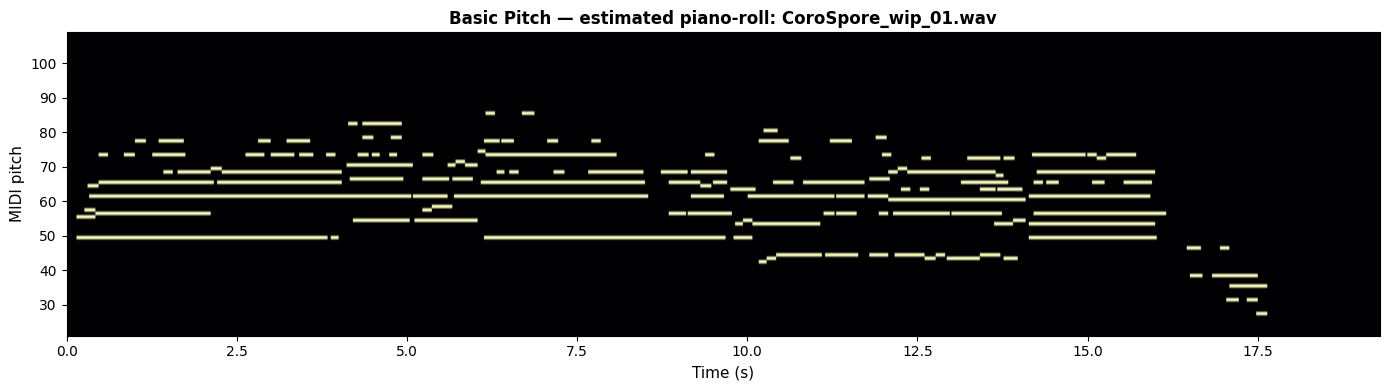


⬇️   Downloading MIDI file...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅  Done


In [3]:
# Cell 5 — Interactive: convert any audio file to MIDI with Basic Pitch
# ─────────────────────────────────────────────────────────────────────────
# Usage:
#   1. Set AUDIO_INPUT to the path of your audio file (wav, mp3, flac, ogg)
#   2. Optionally adjust the thresholds below
#   3. Run the cell — the MIDI is saved to MIDI_OUTPUT and downloaded
# ─────────────────────────────────────────────────────────────────────────

from google.colab import files as colab_files
import IPython.display as ipd

# ── Configuration ────────────────────────────────────────────────────────
AUDIO_INPUT  = None   # set to a path string, or leave None to upload interactively

# Manime settings (1) 0.40 0.3 116  (2) 0.50 0.3 174  (3) 0.50 0.6 174
# (4) 0.50 0.45 174  (5) 0.40 0.40 174   (6) 0.40 0.40 116

# Coro Spore settings (1) 0.30, 0.30, 58  (2) 0.50, 0.50, 116  (3) 0.20, 0.50, 116  (4) 0.50, 0.20, 116
# Coro Spore settings (5) 0.20, 0.32, 116

ONSET_THR    = 0.20    # higher = fewer, more confident onsets      Orig. Val 0.5
FRAME_THR    = 0.20    # higher = fewer active frames (less noisy)  Orig. Val 0.3
MIN_NOTE_MS  = 116     # minimum note duration in milliseconds      Orig. Val 58
MIN_HZ       = None   # minimum pitch frequency (Hz), None = no limit
MAX_HZ       = None   # maximum pitch frequency (Hz), None = no limit

# ── Step 1: get audio file ────────────────────────────────────────────────
if AUDIO_INPUT is None:
    print('📂  No path set — upload an audio file:')
    uploaded = colab_files.upload()
    if not uploaded:
        raise RuntimeError('No file uploaded.')
    AUDIO_INPUT = list(uploaded.keys())[0]
    print(f'   Uploaded: {AUDIO_INPUT}')

audio_path = Path(AUDIO_INPUT)
if not audio_path.exists():
    raise FileNotFoundError(f'Audio file not found: {audio_path}')

print(f'\n🎵  Input  : {audio_path.name}')
print(f'   Duration: {librosa.get_duration(path=str(audio_path)):.1f} s')

# ── Step 2: run Basic Pitch ───────────────────────────────────────────────
midi_out = audio_path.with_suffix('.mid')

print(f'\n🎹  Running Basic Pitch...')
print(f'   onset_threshold={ONSET_THR} | frame_threshold={FRAME_THR} | min_note={MIN_NOTE_MS}ms')

model_output, midi_data, note_events = bp_predict(
    str(audio_path),
    ICASSP_2022_MODEL_PATH,
    onset_threshold=ONSET_THR,
    frame_threshold=FRAME_THR,
    minimum_note_length=MIN_NOTE_MS,
    minimum_frequency=MIN_HZ,
    maximum_frequency=MAX_HZ,
    multiple_pitch_bends = False,
    melodia_trick=False,
)

midi_data.write(str(midi_out))
n_notes = sum(len(inst.notes) for inst in midi_data.instruments)

print(f'\n✅  Transcription complete')
print(f'   Notes detected : {n_notes}')
print(f'   MIDI saved to  : {midi_out}')

# ── Step 3: piano-roll visualisation ─────────────────────────────────────
y_dur    = librosa.get_duration(path=str(audio_path))
n_frames = int(round(y_dur * FRAME_RATE))
pr       = midi_to_pianoroll(midi_data, y_dur)

T_show = min(pr.shape[1], int(60 * FRAME_RATE))   # show max 60 s
times  = np.arange(T_show) / FRAME_RATE

fig, ax = plt.subplots(figsize=(14, 4))
ax.imshow(pr[:, :T_show], aspect='auto', origin='lower', cmap='magma',
          extent=[0, times[-1], 21, 109])
ax.set_xlabel('Time (s)', fontsize=11)
ax.set_ylabel('MIDI pitch', fontsize=11)
ax.set_title(f'Basic Pitch — estimated piano-roll: {audio_path.name}', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(audio_path.with_suffix('.png'), dpi=150, bbox_inches='tight')
plt.show(); plt.close()

# ── Step 4: download MIDI ─────────────────────────────────────────────────
print('\n⬇️   Downloading MIDI file...')
colab_files.download(str(midi_out))
print('✅  Done')